In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow import keras
from tensorflow.keras import layers


df = pd.read_parquet("../data/features/dimuon_features.parquet")

df.head()


,pt1,eta1,phi1,E1,Q1,pt2,eta2,phi2,E2,Q2,M
0,4.2116,2.2366,-0.4849,19.9382,1,1.2556,2.2683,-1.4488,6.1319,-1,2.1330
1,2.1479,-2.0159,-2.7753,8.2066,-1,19.5453,-1.0826,-0.3408,32.1613,1,13.6786
2,21.0732,1.5948,-1.1137,54.0560,1,2.3864,1.5352,-1.7388,5.7968,-1,4.3813
3,18.5889,1.6422,1.1923,49.8180,1,1.8721,1.9704,1.6393,6.8459,-1,3.2587
4,11.8194,0.8711,-1.5811,16.5947,-1,0.9408,2.0107,-1.6559,3.5779,1,4.0171


In [4]:
numeric_cols = [
    "pt1", "eta1", "phi1", "E1", "Q1",
    "pt2", "eta2", "phi2", "E2", "Q2",
    "M"
]

X = df[numeric_cols].copy()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((67008, 11), (16753, 11))

In [7]:
input_dim = X_train.shape[1]

input_layer = keras.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation="relu")(input_layer)
encoded = layers.Dense(4, activation="relu")(encoded)

decoded = layers.Dense(8, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = keras.Model(input_layer, decoded)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=100,
    batch_size=256,
    shuffle=True
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - loss: 0.1941 - val_loss: 0.2706
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.1966 - val_loss: 0.2785
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - loss: 0.1958 - val_loss: 0.2740
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.1941 - val_loss: 0.2695
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 0.1943 - val_loss: 0.2706
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.1965 - val_loss: 0.2734
Epoch 7/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.1989 - val_loss: 0.2752
Epoch 8/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - loss: 0.1995 - val_loss: 0.2695
Epoch 9/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 0.1936 - val_loss: 0.2733
Epoch 10/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - loss: 0.1933 - val_loss: 0.2716
Epoch 11/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - loss: 0.1931 - val_loss: 0.2739
Epoch 12/100
262/26

In [19]:
X_recon = autoencoder.predict(X_scaled)

reconstruction_error = np.mean((X_scaled - X_recon)**2, axis=1)
df["anomaly_score_autoencoder"] = reconstruction_error

2618/2618 ━━━━━━━━━━━━━━━━━━━━ 0s 152us/step


In [20]:
threshold = np.percentile(reconstruction_error, 95)
threshold
df["anomaly_label_autoencoder"] = (df["anomaly_score_autoencoder"] > threshold).astype(int)
df["anomaly_label_autoencoder"] = df["anomaly_label_autoencoder"].replace({0: 1, 1: -1})

In [21]:
output_path = "../data/processed/dimuon_anomaly_autoencoder.parquet"
df.to_parquet(output_path, index=False)
output_path

'../data/processed/dimuon_anomaly_autoencoder.parquet'

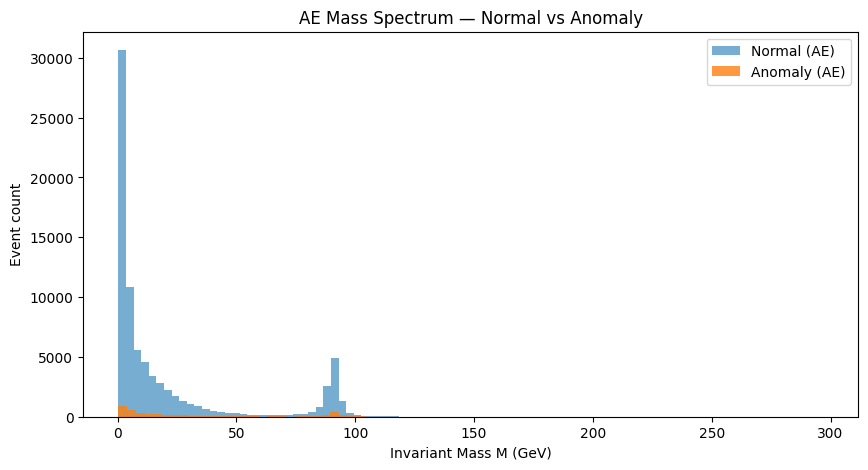

In [22]:
plt.figure(figsize=(10,5))
plt.hist(df[df["anomaly_label_autoencoder"] == 1]["M"], bins=80, alpha=0.6, label="Normal (AE)")
plt.hist(df[df["anomaly_label_autoencoder"] == -1]["M"], bins=80, alpha=0.8, label="Anomaly (AE)")
plt.xlabel("Invariant Mass M (GeV)")
plt.ylabel("Event count")
plt.title("AE Mass Spectrum — Normal vs Anomaly")
plt.legend()
plt.show()

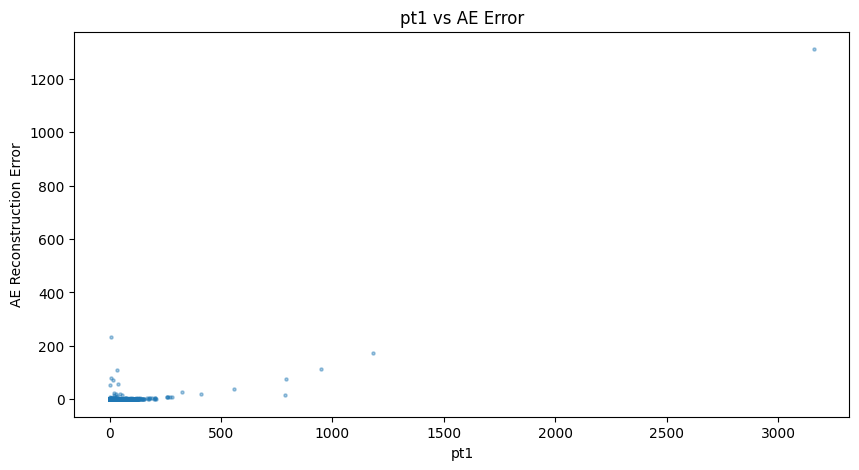

In [23]:
plt.figure(figsize=(10,5))
plt.scatter(df["pt1"], df["anomaly_score_autoencoder"], s=5, alpha=0.4)
plt.xlabel("pt1")
plt.ylabel("AE Reconstruction Error")
plt.title("pt1 vs AE Error")
plt.show()

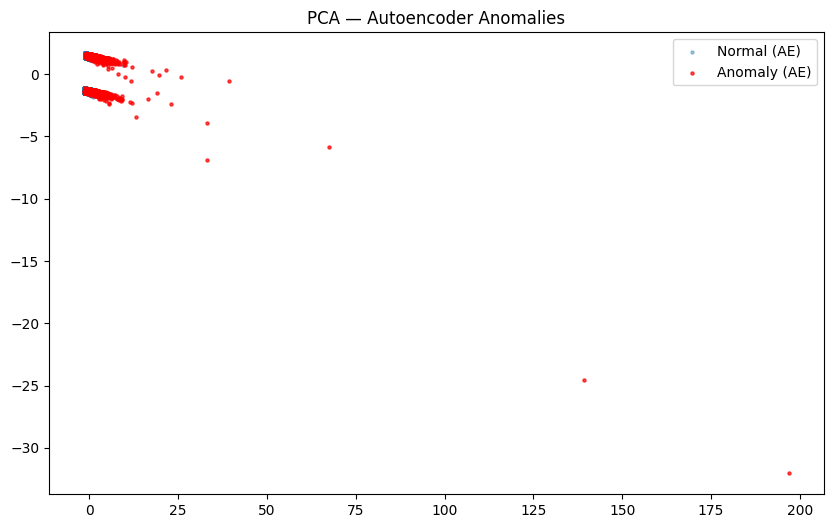

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[df["anomaly_label_autoencoder"] == 1, 0],
    X_pca[df["anomaly_label_autoencoder"] == 1, 1],
    s=5, label="Normal (AE)", alpha=0.4
)
plt.scatter(
    X_pca[df["anomaly_label_autoencoder"] == -1, 0],
    X_pca[df["anomaly_label_autoencoder"] == -1, 1],
    s=5, label="Anomaly (AE)", alpha=0.7, color="red"
)
plt.legend()
plt.title("PCA — Autoencoder Anomalies")
plt.show()